# Unidad 1 — Introducción y Pipeline KDD

> **Inteligencia Computacional · USACH · Prof. Max Chacón**  
> Notebook: exploración introductoria del proceso KDD sobre el dataset Wisconsin Breast Cancer.

**Objetivos del notebook:**
- Recorrer las 5 etapas del proceso KDD (Fayyad, 1996).
- Visualizar la pirámide dato → información → conocimiento.
- Comparar un modelo lineal (regresión logística) con una baseline trivial.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

## 1. Selección de datos

**Etapa KDD 1**: identificar y cargar el subconjunto de datos relevante.

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')  # 0=maligno, 1=benigno

print(f'Instancias : {X.shape[0]}')
print(f'Atributos  : {X.shape[1]}')
print(f'Clases     : {dict(zip(data.target_names, np.bincount(y)))}')

Instancias : 569
Atributos  : 30
Clases     : {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


In [3]:
X.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
mean texture,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
mean perimeter,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
mean area,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
mean smoothness,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
mean compactness,569.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35
mean concavity,569.0,0.09,0.08,0.00,0.03,0.06,0.13,0.43
mean concave points,569.0,0.05,0.04,0.00,0.02,0.03,0.07,0.20
mean symmetry,569.0,0.18,0.03,0.11,0.16,0.18,0.20,0.30
mean fractal dimension,569.0,0.06,0.01,0.05,0.06,0.06,0.07,0.10


## 2. Pre-procesamiento

**Etapa KDD 2**: limpieza y manejo de faltantes.

Faltantes por columna:
0 valores faltantes en total


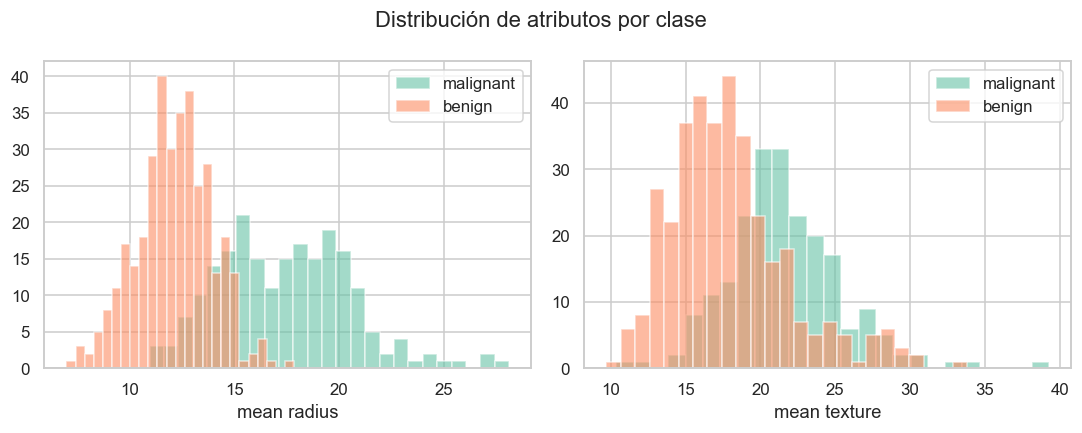

In [4]:
print('Faltantes por columna:')
print(X.isnull().sum().sum(), 'valores faltantes en total')

# Visualizar distribución de un atributo por clase
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, feat in zip(axes, ['mean radius', 'mean texture']):
    for cls, label in zip([0, 1], data.target_names):
        ax.hist(X[feat][y == cls], bins=25, alpha=0.6, label=label)
    ax.set_xlabel(feat)
    ax.legend()
plt.suptitle('Distribución de atributos por clase')
plt.tight_layout()
plt.show()

## 3. Transformación

**Etapa KDD 3**: estandarización + reducción a 2 componentes principales (anticipo PCA).

Varianza explicada PC1: 44.3%
Varianza explicada PC2: 19.0%


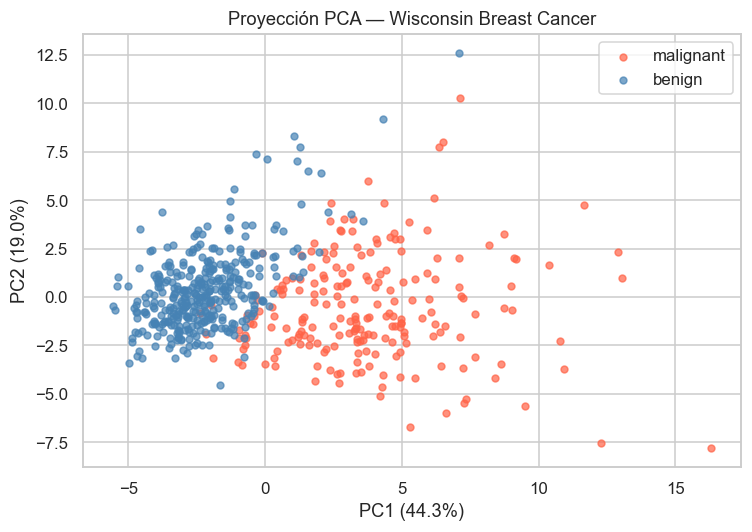

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'Varianza explicada PC1: {pca.explained_variance_ratio_[0]:.1%}')
print(f'Varianza explicada PC2: {pca.explained_variance_ratio_[1]:.1%}')

fig, ax = plt.subplots(figsize=(7, 5))
for cls, label, c in zip([0, 1], data.target_names, ['tomato', 'steelblue']):
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=20, alpha=0.7, label=label, c=c)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Proyección PCA — Wisconsin Breast Cancer')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Minería de Datos

**Etapa KDD 4**: modelo lineal como baseline.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

## 5. Evaluación

**Etapa KDD 5**: métricas e interpretación.

Accuracy : 0.982
ROC-AUC  : 0.995


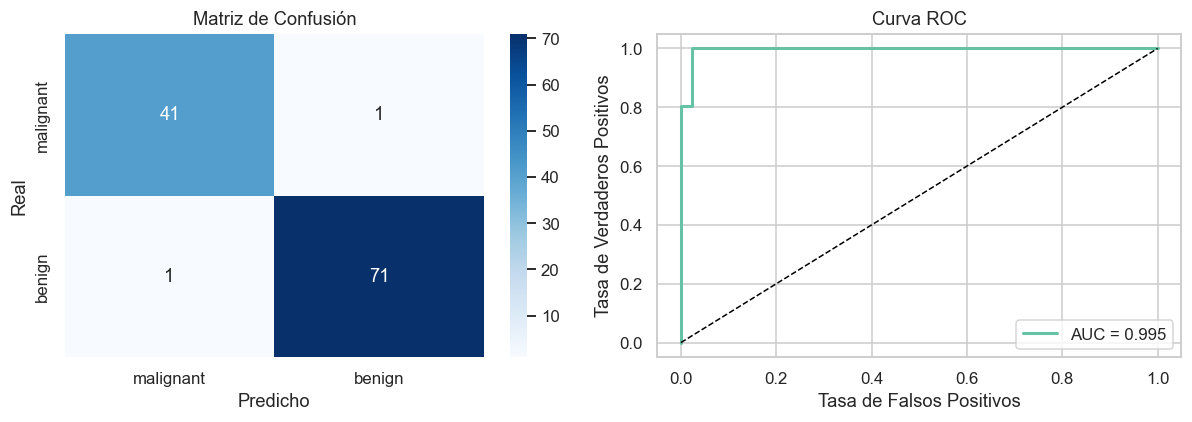

In [7]:
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
print(f'Accuracy : {acc:.3f}')
print(f'ROC-AUC  : {auc:.3f}')

cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Matriz de confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names,
            ax=axes[0])
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')
axes[0].set_title('Matriz de Confusión')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, clf.predict_proba(X_test)[:, 1])
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curva ROC')
axes[1].legend()
plt.tight_layout()
plt.show()

## Resumen del pipeline KDD

| Etapa | Acción realizada | Herramienta |
|---|---|---|
| 1. Selección | Cargar Breast Cancer (569 × 30) | `sklearn.datasets` |
| 2. Pre-procesamiento | Verificar faltantes; histogramas por clase | `pandas`, `matplotlib` |
| 3. Transformación | `StandardScaler` + PCA 2D | `sklearn.preprocessing`, `sklearn.decomposition` |
| 4. Minería | Regresión Logística | `sklearn.linear_model` |
| 5. Evaluación | Accuracy, AUC-ROC, confusión | `sklearn.metrics` |

**Observación**: la separabilidad ya visible en la proyección PCA explica el alto AUC del modelo lineal.